In [1]:
import os
import numpy as np
import cv2
from PIL import Image
from skimage import color
import matplotlib.pyplot as plt

In [2]:
PHOTO_DIR = "photo"
OUTPUT_DIR = "restored"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PROTOTXT = "colorization_deploy_v2.prototxt"
CAFFEMODEL = "colorization_release_v2.caffemodel"
POINTS = "pts_in_hull.npy"

In [3]:
def classify_image(image):
    img_np = np.array(image).astype(np.float32)
    diff = (np.abs(img_np[:, :, 0] - img_np[:, :, 1]).mean() +
            np.abs(img_np[:, :, 1] - img_np[:, :, 2]).mean() +
            np.abs(img_np[:, :, 0] - img_np[:, :, 2]).mean()) / 3

    hsv = cv2.cvtColor(img_np.astype(np.uint8), cv2.COLOR_RGB2HSV)
    sat_mean = hsv[:, :, 1].mean()

    if diff < 8 and sat_mean < 25:
        return 'grayscale'
    return 'color'

In [4]:
def remove_color_cast(image, strength=1.0):
    img_np = np.array(image).astype(np.float32) / 255.0
    lab = color.rgb2lab(img_np)

    L = lab[:, :, 0]
    a = lab[:, :, 1]
    b = lab[:, :, 2]

    a_shift = np.median(a)
    b_shift = np.median(b)

    a_corr = a - a_shift * strength
    b_corr = b - b_shift * strength

    chroma_before = np.sqrt(a**2 + b**2).mean()
    chroma_after = np.sqrt(a_corr**2 + b_corr**2).mean()

    if chroma_after > chroma_before * 1.1:
        a_corr = a - a_shift * strength * 0.5
        b_corr = b - b_shift * strength * 0.5

    lab_out = np.stack([L, a_corr, b_corr], axis=2)
    result = color.lab2rgb(lab_out)
    result = np.clip(result, 0, 1)

    return Image.fromarray((result * 255).astype(np.uint8))

In [5]:
def adjust_lighting(image):
    img_np = np.array(image).astype(np.uint8)
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_new = clahe.apply(l_ch)

    lab_new = cv2.merge([l_new, a_ch, b_ch])
    result = cv2.cvtColor(lab_new, cv2.COLOR_LAB2RGB)
    return Image.fromarray(result)

In [6]:
def load_colorization_model():
    if not (os.path.exists(PROTOTXT) and os.path.exists(CAFFEMODEL) and os.path.exists(POINTS)):
        print("⚠️ Файлы модели раскраски не найдены.")
        return None

    net = cv2.dnn.readNetFromCaffe(PROTOTXT, CAFFEMODEL)
    pts = np.load(POINTS)

    class8_ab = net.getLayerId("class8_ab")
    conv8_313_rh = net.getLayerId("conv8_313_rh")
    pts = pts.transpose().reshape(2, 313, 1, 1)
    net.getLayer(class8_ab).blobs = [pts.astype(np.float32)]
    net.getLayer(conv8_313_rh).blobs = [np.full([1, 313], 2.606, dtype=np.float32)]
    return net

In [7]:
def colorize_grayscale(image, net):
    img_np = np.array(image.convert("RGB")).astype(np.float32) / 255.0
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    L = lab[:, :, 0]
    L_resized = cv2.resize(L, (224, 224)) - 50

    net.setInput(cv2.dnn.blobFromImage(L_resized))
    ab = net.forward()[0, :, :, :].transpose((1, 2, 0))
    ab = cv2.resize(ab, (img_np.shape[1], img_np.shape[0]))

    lab_output = np.concatenate((L[:, :, np.newaxis], ab), axis=2)
    bgr = cv2.cvtColor(lab_output, cv2.COLOR_LAB2BGR)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = np.clip(rgb, 0, 1)
    return Image.fromarray((rgb * 255).astype(np.uint8))

Найдено: 5 изображений

Обработка: 1.jpg  [color]
  → Восстановлено: restored\nofilter_1.jpg


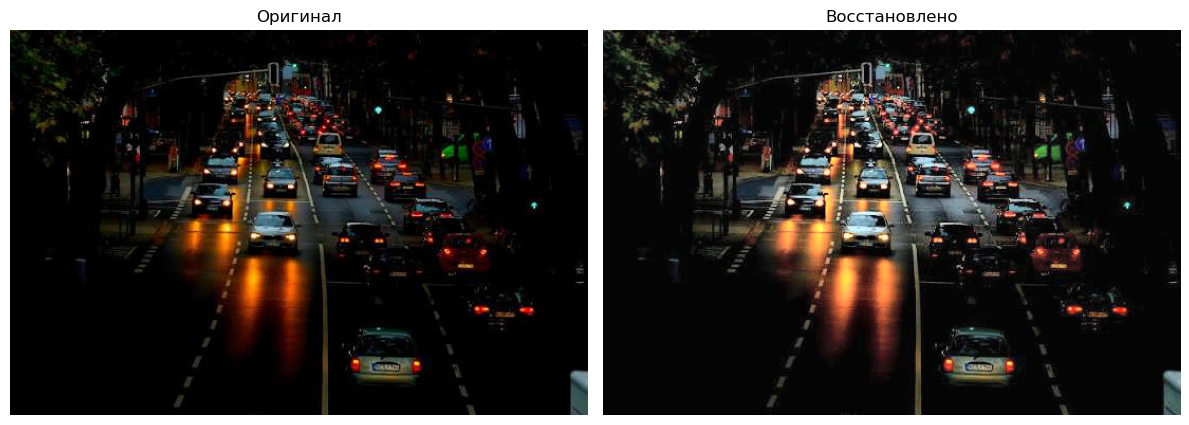

Обработка: 2.jpg  [color]
  → Восстановлено: restored\nofilter_2.jpg


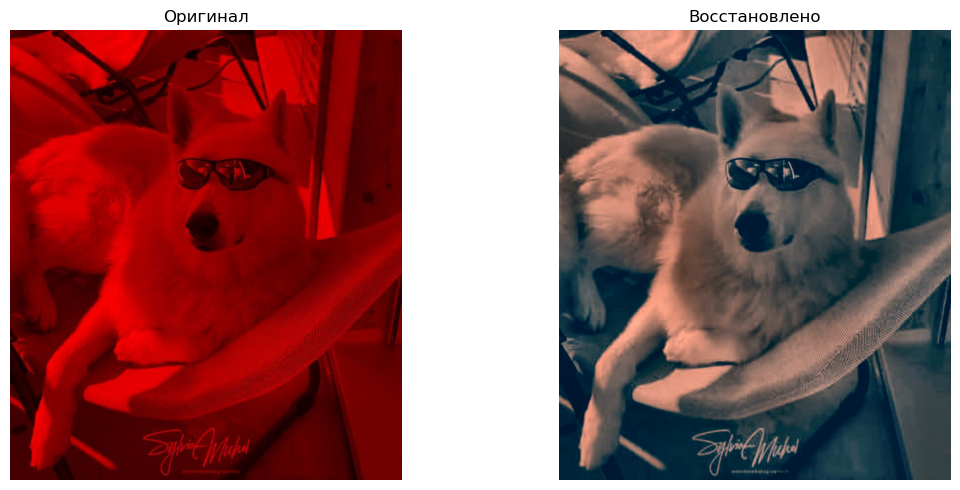

Обработка: 3.jpg  [color]
  → Восстановлено: restored\nofilter_3.jpg


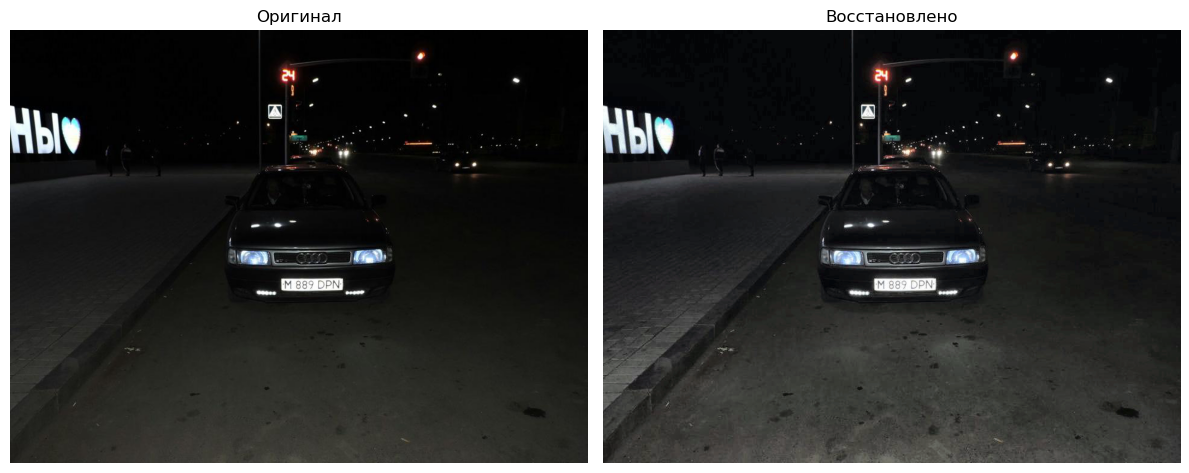

Обработка: 4.jpg  [color]
  → Восстановлено: restored\nofilter_4.jpg


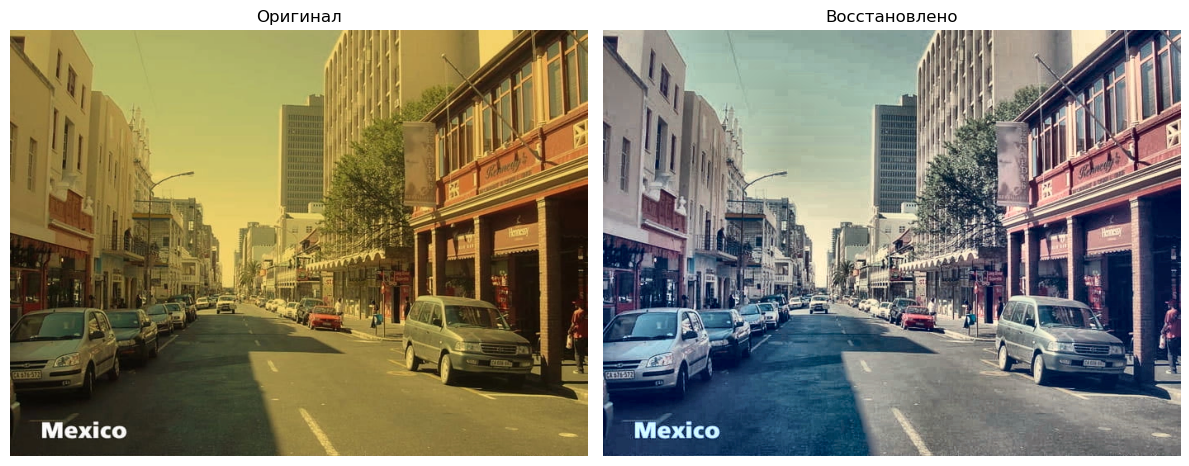

Обработка: 5.jpg  [grayscale]
  → Раскрашено: restored\colorized_5.jpg


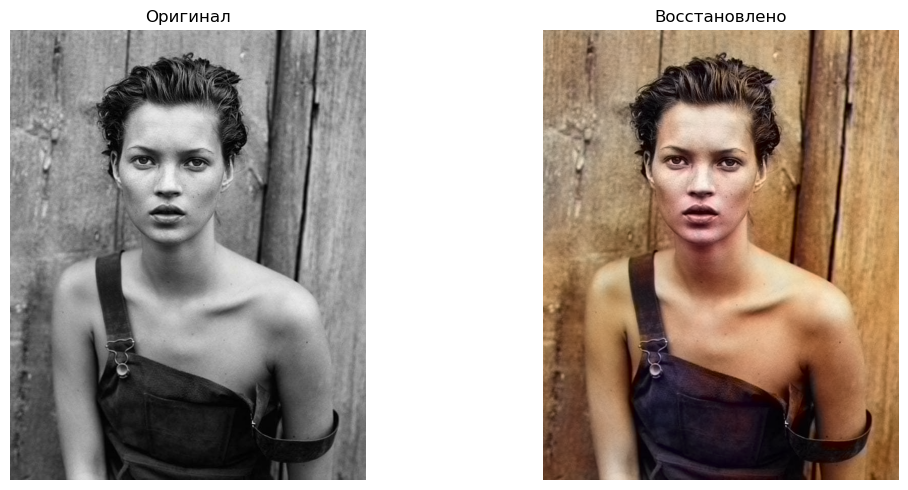

In [8]:
def main():
    net = load_colorization_model()

    extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    images = []
    for f in os.listdir(PHOTO_DIR):
        if f.lower().endswith(extensions):
            img = Image.open(os.path.join(PHOTO_DIR, f)).convert("RGB")
            images.append((f, img))

    if not images:
        print(f"❌ В папке '{PHOTO_DIR}' нет изображений.")
        return

    print(f"Найдено: {len(images)} изображений\n")

    for filename, img in images:
        kind = classify_image(img)
        print(f"Обработка: {filename}  [{kind}]")

        if kind == 'grayscale':
            if net is None:
                print("  → Модель раскраски недоступна, пропущено.")
                continue

            result = colorize_grayscale(img, net)
            out_path = os.path.join(OUTPUT_DIR, f"colorized_{filename}")
            result.save(out_path)
            print(f"  → Раскрашено: {out_path}")
        else:
            no_cast = remove_color_cast(img, strength=1.0)
            final = adjust_lighting(no_cast)

            out_path = os.path.join(OUTPUT_DIR, f"nofilter_{filename}")
            final.save(out_path)
            print(f"  → Восстановлено: {out_path}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img); axes[0].set_title("Оригинал"); axes[0].axis('off')
        axes[1].imshow(result if kind == 'grayscale' else final)
        axes[1].set_title("Восстановлено"); axes[1].axis('off')
        plt.tight_layout(); plt.show()

if __name__ == "__main__":
    main()